In [1]:
import velocycle as vc
from velocycle import *

# generic & ml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyro
import copy
import scipy
import pycircstat
import pickle
from scipy.stats import pearsonr
from scipy.linalg import lstsq
import statsmodels.api as sm

# scRNA-seq
import scanpy as sc
import anndata


import os

In [71]:
ct = "BWM"
velocity_fit0 = pickle.load(open("../intermediates/2502/250409_anndata/"+ct+"_velocity_fit0.pkl", "rb"))
velocity_fit1 = pickle.load(open("../intermediates/2502/250409_anndata/"+ct+"_velocity_fit1.pkl", "rb"))

In [4]:
velocity_fit0.posterior['logγg'].shape
#velocity_fit0.posterior['logγg'][0,0,0,:,0]

torch.Size([500, 1, 1, 966, 1])

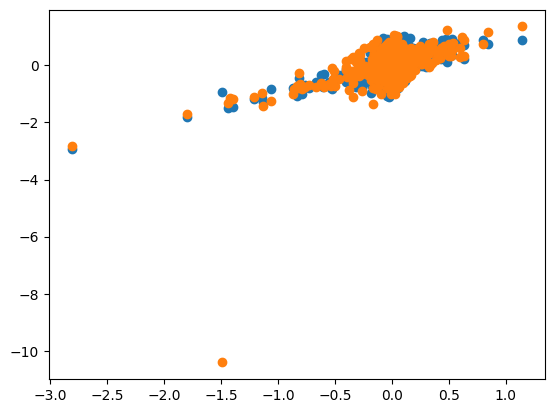

In [123]:
plt.scatter(velocity_fit0.log_gammas, 
                velocity_fit0.posterior['logγg'][0,0,0,:,0])
plt.scatter(velocity_fit0.log_gammas, 
                velocity_fit0.posterior['logγg'][499,0,0,:,0])

plt.show()

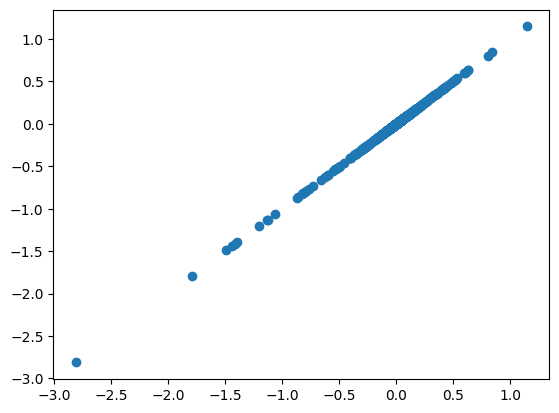

In [9]:


plt.scatter(velocity_fit0.log_gammas, 
                velocity_fit0.posterior['logγg'].squeeze().mean(0))

plt.show()

In [14]:
pd.DataFrame(velocity_fit0.log_gammas, velocity_fit0.posterior['logγg'].squeeze().mean(0).numpy())

,0
0.059912,0.059912
-0.037995,-0.037995
0.017632,0.017632
0.026791,0.026791
-0.163159,-0.163159
...,...
0.016253,0.016253
0.077783,0.077783
-0.006905,-0.006905
0.068835,0.068835


In [13]:
type(velocity_fit0.posterior['logγg'].squeeze().mean(0))


torch.Tensor

In [44]:
velocity_fit0.posterior.keys()

dict_keys(['logγg', 'logβg', 'rho_real', 'νω', 'γg', 'ν', 'ϕxy', 'ϕ', 'ζ', 'ζ_dϕ', 'ζω', 'ω', 'shape_inv', 'ElogS', 'ElogU', 'ElogS2', 'ElogU2'])

In [45]:
velocity_fit0.posterior['logβg'].shape

torch.Size([500, 1, 1, 1004, 1])

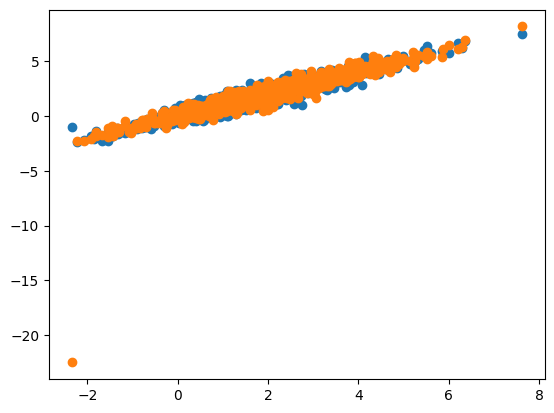

In [3]:
plt.scatter(velocity_fit0.log_betas, 
                velocity_fit0.posterior['logβg'][0,0,0,:,0])
plt.scatter(velocity_fit0.log_betas, 
                velocity_fit0.posterior['logβg'][499,0,0,:,0])

plt.show()

In [4]:

# Function to save each tensor as a separate CSV (from ChatGPT)
def save_tensors_to_csv(ct, velocity_fit0_posterior, model):
    # Ensure the directory exists (if you want to store CSVs in a specific folder)
    os.makedirs(ct, exist_ok=True)

    # Iterate through the posterior dictionary and save each tensor to a separate CSV
    for key, tensor in velocity_fit0_posterior.items():
        arr = tensor.detach().squeeze().numpy()
        
        # Prepare the filename
        filename = f"{ct}/{model}_{key}.csv"

        # Handle tensor dimensions
        if arr.ndim == 1:
            # 1D tensor: Save as a single-column CSV
            df = pd.DataFrame(arr, columns=[key])
        
        elif arr.ndim == 2:
            # 2D tensor: Save as a multi-column CSV
            df = pd.DataFrame(arr, columns=[f"{key}_{i}" for i in range(arr.shape[1])])
        
        elif arr.ndim == 3:
            # 3D tensor: Flatten last two dimensions and save as a multi-column CSV
            flat = arr.reshape(arr.shape[0], -1)  # Flatten the last two dimensions
            df = pd.DataFrame(flat, columns=[f"{key}_{i}" for i in range(flat.shape[1])])
        
        else:
            raise ValueError(f"Tensor '{key}' has unsupported shape {arr.shape}.")

        # Save DataFrame to CSV
        df.to_csv(filename, index=False)
        print(f"Saved {filename}")


In [120]:

# Call the function to save the tensors
save_tensors_to_csv(ct, velocity_fit1.posterior, "fit1")
save_tensors_to_csv(ct, velocity_fit1.posterior, "fit1")

pd.DataFrame({"phi": velocity_fit0.phase_pyro.phis}).to_csv(ct+"_cell_phi0.csv")
pd.DataFrame({"phi": velocity_fit1.phase_pyro.phis}).to_csv(ct+"_cell_phi1.csv")


Saved ILso/fit1_logγg.csv
Saved ILso/fit1_logβg.csv
Saved ILso/fit1_rho_real.csv
Saved ILso/fit1_νω.csv
Saved ILso/fit1_γg.csv
Saved ILso/fit1_ν.csv
Saved ILso/fit1_ϕxy.csv
Saved ILso/fit1_ϕ.csv
Saved ILso/fit1_ζ.csv
Saved ILso/fit1_ζ_dϕ.csv
Saved ILso/fit1_ζω.csv
Saved ILso/fit1_ω.csv
Saved ILso/fit1_shape_inv.csv
Saved ILso/fit1_ElogS.csv
Saved ILso/fit1_ElogU.csv
Saved ILso/fit1_ElogS2.csv
Saved ILso/fit1_ElogU2.csv


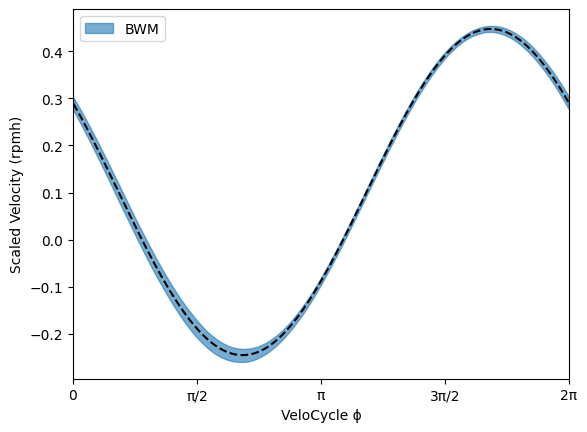

In [93]:
data = sc.read_h5ad("../intermediates/2502/250409_anndata/"+ct+".h5ad")
data.obs["batch"] = ct
sc.pp.filter_genes(data, min_cells=int((data.n_obs)*0.005))
data = data[:, (data.layers["unspliced"].toarray().mean(0) > 0.01)].copy()
data = data[:, data.layers["spliced"].toarray().mean(0) > 0.01].copy()


# create prior
full_keep_genes = data.var_names
cycle_prior = cycle.Cycle.trivial_prior(gene_names=full_keep_genes, harmonics=1)
# Keep only genes from biologically-relevant gene set that are present in the current dataset
cycle_prior, data_to_fit = preprocessing.filter_shared_genes(cycle_prior, data, filter_type="intersection")


# Put estimations in new objects
cycle_pyro = velocity_fit1.cycle_pyro
phase_pyro = velocity_fit1.phase_pyro
speed_pyro = velocity_fit1.speed_pyro

fit_ElogS = velocity_fit1.posterior["ElogS"].squeeze()
fit_ElogU = velocity_fit1.posterior["ElogU"].squeeze()

fit_ElogS2 = velocity_fit1.posterior["ElogS2"].squeeze()
fit_ElogU2 = velocity_fit1.posterior["ElogU2"].squeeze()

log_gammas = velocity_fit1.log_gammas
log_betas = velocity_fit1.log_betas

speed_pyro.means

# Store entire posterior sampling into an object
full_pps_velo = velocity_fit1.posterior

# Visualize the constant velocity estimate
omega = full_pps_velo["ω"].squeeze().numpy() / torch.exp(torch.mean(full_pps_velo["logγg"].squeeze().mean(0).detach())).numpy()
phi = phase_pyro.phis
omegas = []
phis = []
n2n = {ct:0}
ids = np.array([n2n[i] for i in np.array(data_to_fit.obs["batch"])])
for i in range(len(data_to_fit.obs["batch"].unique())):
    omega1 = omega[:,np.where(ids == i)]
    phi1 = phi[np.where(ids == i)]
    omegas.append(omega1)
    phis.append(phi1)

labels = np.array(data_to_fit.obs["batch"].unique())

colors = ["tab:blue"]
for i in range(len(omegas)):
    plt.plot(phis[i][np.argsort(phis[i])], omegas[i].mean(0)[0][np.argsort(phis[i])], c="black", linestyle='dashed')
    
    tmp5 = np.percentile(omega[:, ids==i], 5, axis=0)
    tmp95 = np.percentile(omega[:, ids==i], 95, axis=0)
    phi_i = phi[ids==i] 
    plt.fill_between(x=phi_i[np.argsort(phi_i)],
                     y1=tmp5[np.argsort(phi_i)], 
                     y2=tmp95[np.argsort(phi_i)], 
                     alpha=0.6, color=colors[i], label = labels[i])

plt.xlabel("VeloCycle ϕ")
plt.ylabel("Scaled Velocity (rpmh)")
plt.xlim(0, 2*np.pi)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],["0", "π/2", "π", "3π/2", "2π"])
plt.legend()
plt.show()



In [90]:
omega.min(axis = 0)

array([0.3404853, 0.3404853, 0.3404853, ..., 0.3404853, 0.3404853,
       0.3404853], dtype=float32)

In [74]:
ct

'BWM'